In [ ]:
'''
Members: Lauren Nunez, Regina Martinez, Saam Grami
'''

'\nMembers: Lauren Nunez, Regina Martinez, Saam Grami\n'

In [12]:
'''
Data prep
1. Put data into arrays or lists per class
2. Convert all data into a certain height and width 
3. Put 100 pictures into validation and the rest into training
'''


#Potential dimension resizer
import cv2

# Target dimensions
new_size = (224, 224) 

# Load image
img = cv2.imread("input_image.jpg")

# Resize the image
resized_img = cv2.resize(img, new_size, interpolation=cv2.INTER_AREA) # Use INTER_AREA for downsampling


[ WARN:0@478.542] global loadsave.cpp:278 findDecoder imread_('input_image.jpg'): can't open/read file: check file path/integrity


error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


In [ ]:
'''
1. Generate independent training, validation, and test sets from the dataset.
2. The validation set must contain 500 images, with 100 images from each flower category.
3. The test set must contain 500 images, with 100 images from each flower category.
4. Assign all remaining images to the training set and make sure the three splits are fully independent.
5. Build a CNN with multiple convolution and max-pooling layers.
6. Train on the training set, evaluate on the validation set after each epoch, and report final performance on the test set.
7. Tune the network depth and layer sizes to improve test accuracy.
8. Display the training and validation accuracy histories and print the final test accurac
'''


'\n1. Generate independent training, validation, and test sets from the dataset.\n2. The validation set must contain 500 images, with 100 images from each flower category.\n3. The test set must contain 500 images, with 100 images from each flower category.\n4. Assign all remaining images to the training set and make sure the three splits are fully independent.\n5. Build a CNN with multiple convolution and max-pooling layers.\n6. Train on the training set, evaluate on the validation set after each epoch, and report final performance on the test set.\n7. Tune the network depth and layer sizes to improve test accuracy.\n8. Display the training and validation accuracy histories and print the final test accurac\n'

In [ ]:
'''
Activate venv
    source /home/acrfa/ml-class/.venv/bin/activate
'''

'\nActivate venv\n    source /home/acrfa/ml-class/.venv/bin/activate\n'

In [ ]:
# 1. Generate independent training, validation, and test sets from the dataset.
'''
To get the data set we should install kaggle:
    https://stackoverflow.com/questions/77890757/how-can-i-import-data-from-kaggle-while-not-downloading-it#:~:text=You%20can%20import%20data%20from%20Kaggle%20without,clicking%20**Add%20Data**%20in%20the%20right%20menu
    pip install kaggle #for py
    pip install kagglehub #for notebooks

How to download kaggle libraries into ipynb
    https://www.geeksforgeeks.org/python/how-to-download-kaggle-datasets-into-jupyter-notebook/
    
Different kaggle splitting methods
    https://www.kaggle.com/discussions/general/448072

Kaggle example
    https://www.kaggle.com/code/kanchana1990/exoplanet-intelligence
'''
import opendatasets as od
import pandas
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from pathlib import Path    

#This line downloads the photos to the local file
od.download("https://www.kaggle.com/datasets/muratkokludataset/acoustic-extinguisher-fire-dataset")
#This line takes the URL and makes it into a file
DATASET_URL = "https://www.kaggle.com/datasets/muratkokludataset/acoustic-extinguisher-fire-dataset"

dataset_folder = Path("flowers-dataset")
print(f"Downloaded to: {dataset_folder.resolve()}")

all_files =list(dataset_folder.rglob("*"))
print(f"\nTotal files: {len(all_files)}")
    
for f in all_files[:20]:          # preview first 20
    print(" ", f)




Skipping, found downloaded files in "./acoustic-extinguisher-fire-dataset" (use force=True to force download)
Downloaded to: /home/acrfa/ml-class/mtre4820_project4/flowers-dataset

Total files: 9481
  flowers-dataset/Testing_set_flower.csv
  flowers-dataset/2481823240_eab0d86921.jpg
  flowers-dataset/flowers_split
  flowers-dataset/LICENSE.txt
  flowers-dataset/train
  flowers-dataset/test
  flowers-dataset/2481823240_eab0d86921.jpg:Zone.Identifier
  flowers-dataset/flowers_split2
  flowers-dataset/sample_submission.csv
  flowers-dataset/flowers_split/train
  flowers-dataset/flowers_split/test
  flowers-dataset/flowers_split/validation
  flowers-dataset/train/dandelion
  flowers-dataset/train/tulip
  flowers-dataset/train/rose
  flowers-dataset/train/daisy
  flowers-dataset/train/sunflower
  flowers-dataset/test/Image_650.jpg
  flowers-dataset/test/Image_219.jpg
  flowers-dataset/test/Image_787.jpg


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
# import warnings
import warnings
# filter warnings
warnings.filterwarnings('ignore')

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os


# Any results you write to the current directory are saved as output

Skipping, found downloaded files in "./flowers-dataset" (use force=True to force download)
Downloaded to: /home/acrfa/ml-class/mtre4820_project4/flowers-dataset

Total files: 5174
  flowers-dataset/Testing_set_flower.csv
  flowers-dataset/2481823240_eab0d86921.jpg
  flowers-dataset/flowers_split
  flowers-dataset/LICENSE.txt
  flowers-dataset/train
  flowers-dataset/test
  flowers-dataset/2481823240_eab0d86921.jpg:Zone.Identifier
  flowers-dataset/sample_submission.csv
  flowers-dataset/flowers_split/train
  flowers-dataset/flowers_split/test
  flowers-dataset/flowers_split/validation
  flowers-dataset/train/dandelion
  flowers-dataset/train/tulip
  flowers-dataset/train/rose
  flowers-dataset/train/daisy
  flowers-dataset/train/sunflower
  flowers-dataset/test/Image_650.jpg
  flowers-dataset/test/Image_219.jpg
  flowers-dataset/test/Image_787.jpg
  flowers-dataset/test/Image_696.jpg

Images found: 5144
Showing: flowers-dataset/test/Image_650.jpg


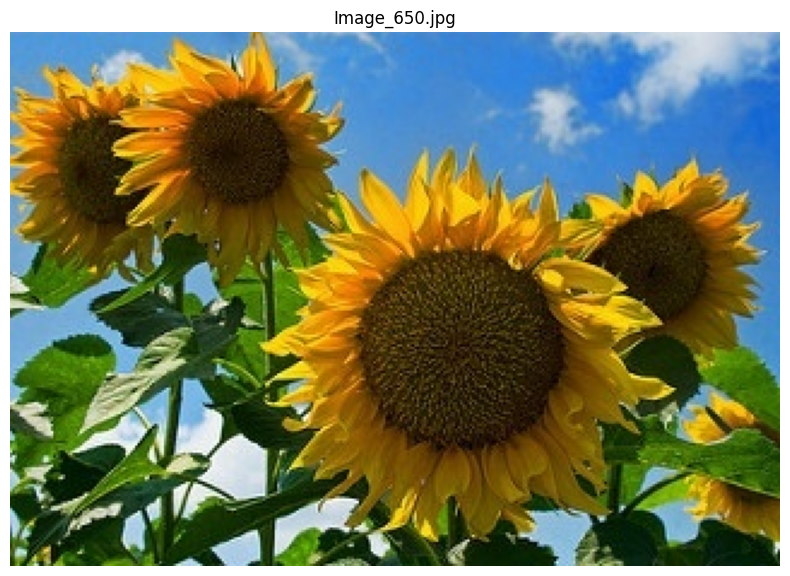

Saved preview to preview_image.png


In [ ]:
import opendatasets as od
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

# ── 1. Download the dataset ────────────────────────────────────────────────
# opendatasets will prompt you for your Kaggle username + API key once,
# then cache credentials at ~/.kaggle/kaggle.json for future runs.
DATASET_URL = "https://www.kaggle.com/datasets/imsparsh/flowers-dataset/data"

od.download(DATASET_URL)   # downloads into ./acoustic-extinguisher-fire-dataset/

# ── 2. Find the downloaded folder ─────────────────────────────────────────
dataset_folder = Path("flowers-dataset")
print(f"Downloaded to: {dataset_folder.resolve()}")

# ── 3. List all files so you know what's there ────────────────────────────
all_files = list(dataset_folder.rglob("*"))
print(f"\nTotal files: {len(all_files)}")
for f in all_files[:20]:          # preview first 20
    print(" ", f)

# ── 4. Find image files ───────────────────────────────────────────────────
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".gif", ".bmp", ".webp"}
images = [f for f in all_files if f.suffix.lower() in IMAGE_EXTENSIONS]
print(f"\nImages found: {len(images)}")

# ── 5. Display the first image ────────────────────────────────────────────
if images:
    img_path = images[1]
    print(f"Showing: {img_path}")

    img = mpimg.imread(str(img_path))

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("preview_image.png", dpi=150)   # save a copy
    plt.show()
    print("Saved preview to preview_image.png")
else:
    print("No image files found in this dataset.")
    print("This dataset may be CSV/tabular only. Files found:")
    for f in all_files:
        print(" ", f)

In [ ]:
from pathlib import Path

folder_path = Path('/home/acrfa/ml-class/mtre4820_project4/flowers-dataset/train') # Replace with your folder's path
file_paths = [str(file) for file in folder_path.iterdir() if file.is_file()]

# 'file_paths' is a list of strings containing all file paths in the directory
print(file_paths)

file_names = [file.name for file in folder_path.iterdir() if file.is_file()]
print(file_names) # Output: ['file1.txt', 'image.png']


[]
[]


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
%matplotlib inline

import tensorflow
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense

print(f'Tensorflow version: {tensorflow.__version__}')
print(f'Keras version: {keras.__version__}')

2026-03-26 17:11:30.402211: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-26 17:11:30.436682: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-26 17:11:31.726545: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-26 17:11:35.678660: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

Tensorflow version: 2.20.0
Keras version: 3.13.1


Total classes are: 5


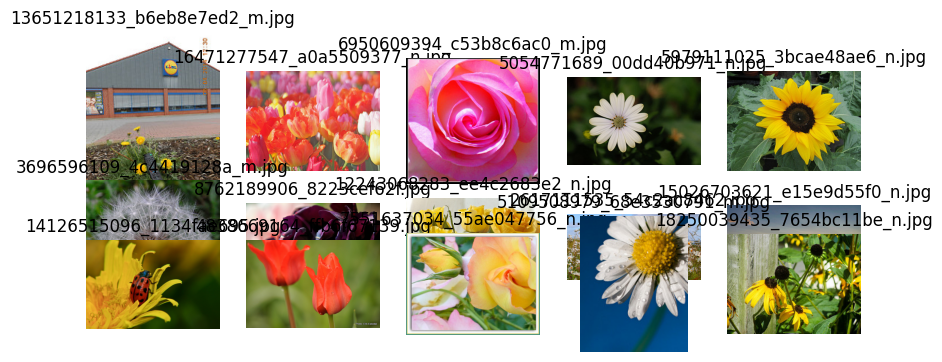

In [ ]:
# Images are in "/home/acrfa/ml-class/mtre4820_project4/flowers-dataset/train" folder
data_folder = '/home/acrfa/ml-class/mtre4820_project4/flowers-dataset/train'

# Get the class names
classes = os.listdir(data_folder) #gives number of classes
classes.sort()
print(f'Total classes are: {len(classes)}')

# Show the first image in each folder
fig = plt.figure(figsize=(10,6))
i = 0
for j in range(3):

    for sub_dir in os.listdir(data_folder):
        i+=1 #Counter
        img_file_name = os.listdir(os.path.join(data_folder,sub_dir))[0+j] #pseudo is list_names(join_path_to_folder)[index]
        img_path_data = os.path.join(data_folder, sub_dir, img_file_name) #full path to that image
        #These two lines above essentially get the name of the image and the image itself respectively
        img = mpimg.imread(img_path_data) #Takes image from folder and puts into variable, formated as (w,g,RGB) example (240, 180, 3)

        a = fig.add_subplot(1+j, len(classes), i) #pseudo table(# of rows, # of cols, the specific cell), this is just making a table to hold the images 
        a.axis('off')   
        imgplot = plt.imshow(img) #displays images, just like project 1
        a.set_title(img_file_name) #Prints two numbers and image name, "Text(0.5, 1.0, '13651218133_b6eb8e7ed2_m.jpg')" is an example
        
plt.show()



Total classes are: 5


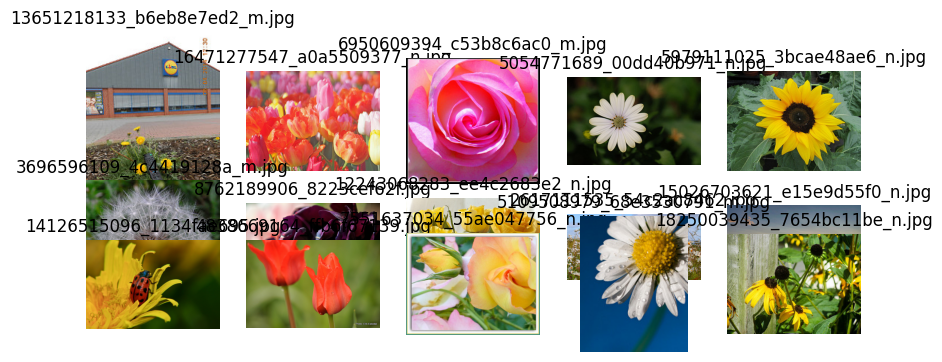

In [ ]:
# Images are in "/home/acrfa/ml-class/mtre4820_project4/flowers-dataset/train" folder
data_folder = '/home/acrfa/ml-class/mtre4820_project4/flowers-dataset/train'

# Get the class names
classes = os.listdir(data_folder) #gives number of classes
classes.sort()
print(f'Total classes are: {len(classes)}')

# Show the first image in each folder
fig = plt.figure(figsize=(10,6))
i = 0
for j in range(3):

    for sub_dir in os.listdir(data_folder):
        i+=1 #Counter
        img_file_name = os.listdir(os.path.join(data_folder,sub_dir))[0+j] #pseudo is list_names(join_path_to_folder)[index]
        img_path_data = os.path.join(data_folder, sub_dir, img_file_name) #full path to that image
        #These two lines above essentially get the name of the image and the image itself respectively
        img = mpimg.imread(img_path_data) #Takes image from folder and puts into variable, formated as (w,g,RGB) example (240, 180, 3)

        a = fig.add_subplot(1+j, len(classes), i) #pseudo table(# of rows, # of cols, the specific cell), this is just making a table to hold the images 
        a.axis('off')   
        imgplot = plt.imshow(img) #displays images, just like project 1
        a.set_title(img_file_name) #Prints two numbers and image name, "Text(0.5, 1.0, '13651218133_b6eb8e7ed2_m.jpg')" is an example
        
plt.show()





In [ ]:
'''
pseudo code
for len(classes) ((this is 5))
    Get folder address
    Create numpy array(len folder)
    picks 100 numbers out of the len(folder) to be put into validation, this will be a bool array
    for r in range(len(folder))
        determines if goes to training or validation
        takes image
        encodes into array
       
'''

i = 0
for sub_dir in os.listdir(data_folder):
    i+=1
    np.array.

Image array shape: (385, 500, 3)
Image data type: uint8


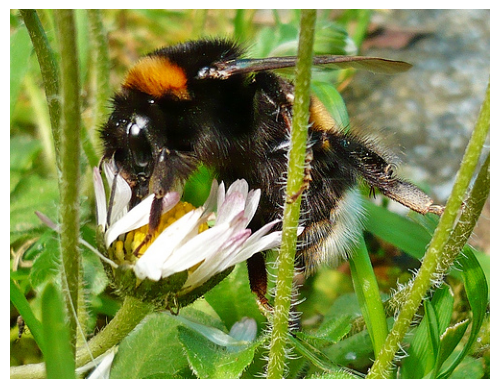

In [ ]:
from PIL import Image
# Open the image file
image = Image.open('/home/acrfa/ml-class/mtre4820_project4/flowers-dataset/2481823240_eab0d86921.jpg')

# Convert the image to a NumPy array
image_array = np.asarray(image)

print(f"Image array shape: {image_array.shape}")
print(f"Image data type: {image_array.dtype}")

# Display the array as an image
plt.imshow(image_array)
plt.axis('off') # Optional: turns off axis numbers
plt.show()

In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import pathlib
import os, shutil
import keras
import random

original_dataset_dir = Path('/home/acrfa/ml-class/mtre4820_project4/flowers-dataset/train')
base_dir = Path('/home/acrfa/ml-class/mtre4820_project4/flowers-dataset/flowers_split')

# slashes, '/', join paths
train_dir = base_dir / 'train'
val_dir = base_dir / 'validation'
test_dir = base_dir / 'test'
 

#defines the daisy validation path
val_daisy_dir = base_dir / 'validation' / 'daisy'
#defines the daisy test path
test_daisy_dir = base_dir / 'test' / 'daisy'
#defines the daisy train path
train_daisy_dir = base_dir / 'train' / 'daisy'
 
 
#makes the daisy validation directory
val_daisy_dir.mkdir(parents=True, exist_ok=True ) #Essentially this says create a folder if nothing there or leave the folder if it is there
#makes the daisy test directory
test_daisy_dir.mkdir(parents=True, exist_ok=True)
#makes the daisy train directory
train_daisy_dir.mkdir(parents=True, exist_ok=True)

#daisy
#goes into dasiy file and stores every pic as a list
daisy_pics = list((original_dataset_dir / 'daisy').iterdir())
#shuffle so not same pic everytime
random.shuffle(daisy_pics)
#loop through first 100 pics for validation set (will do 100 from each type, 500 total) and puts in proper folder
for img in daisy_pics[:100]:
    (base_dir / 'validation' / 'daisy' / img.name).write_bytes(img.read_bytes())
#loops through next 100 pics for test set (will do 100 from each type, 500 total) and puts in proper folder
for img in daisy_pics[100:200]:
    (base_dir / 'test' / 'daisy' / img.name).write_bytes(img.read_bytes())
#assign all remaining images to training set
for img in daisy_pics[200:]:
    (base_dir / 'train' / 'daisy' / img.name).write_bytes(img.read_bytes())

2026-03-27 14:15:31.192883: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-27 14:15:31.224545: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-27 14:15:32.485560: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-27 14:15:37.641653: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [13]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import pathlib
import os, shutil
import keras
import random
from pathlib import Path
import cv2


original_dataset_dir = Path('/home/acrfa/ml-class/mtre4820_project4/flowers-dataset/train')
base_dir = Path('/home/acrfa/ml-class/mtre4820_project4/flowers-dataset/flowers_split')


classes = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

# slashes, '/', join paths
train_dir = base_dir / 'train'
val_dir = base_dir / 'validation'
test_dir = base_dir / 'test'

train_dir.mkdir(parents=True, exist_ok=True)
val_dir.mkdir(parents=True, exist_ok=True)
test_dir.mkdir(parents=True, exist_ok=True)

#Creates all folders for splits

#defines the daisy validation path
val_daisy_dir = base_dir / 'validation' / classes[0]
#defines the daisy test path
test_daisy_dir = base_dir / 'test' / classes[0]
#defines the daisy train path
train_daisy_dir = base_dir / 'train' / classes[0]


#makes the daisy validation directory
val_daisy_dir.mkdir(parents=True, exist_ok=True ) #Essentially this says create a folder if nothing there or leave the folder if it is there
#makes the daisy test directory
test_daisy_dir.mkdir(parents=True, exist_ok=True)
#makes the daisy train directory
train_daisy_dir.mkdir(parents=True, exist_ok=True)



#defines the daisy validation path
val_dandelion_dir = base_dir / 'validation' / classes[1]
#defines the daisy test path
test_dandelion_dir = base_dir / 'test' / classes[1]
#defines the daisy train path
train_dandelion_dir = base_dir / 'train' / classes[1]


#makes the daisy validation directory
val_dandelion_dir.mkdir(parents=True, exist_ok=True ) #Essentially this says create a folder if nothing there or leave the folder if it is there
#makes the daisy test directory
test_dandelion_dir.mkdir(parents=True, exist_ok=True)
#makes the daisy train directory
train_dandelion_dir.mkdir(parents=True, exist_ok=True)




#defines the daisy validation path
val_rose_dir = base_dir / 'validation' / classes[2]
#defines the daisy test path
test_rose_dir = base_dir / 'test' / classes[2]
#defines the daisy train path
train_rose_dir = base_dir / 'train' / classes[2]


#makes the daisy validation directory
val_rose_dir.mkdir(parents=True, exist_ok=True ) #Essentially this says create a folder if nothing there or leave the folder if it is there
#makes the daisy test directory
test_rose_dir.mkdir(parents=True, exist_ok=True)
#makes the daisy train directory
train_rose_dir.mkdir(parents=True, exist_ok=True)



#defines the daisy validation path
val_sunflower_dir = base_dir / 'validation' / classes[3]
#defines the daisy test path
test_sunflower_dir = base_dir / 'test' / classes[3]
#defines the daisy train path
train_sunflower_dir = base_dir / 'train' / classes[3]


#makes the daisy validation directory
val_sunflower_dir.mkdir(parents=True, exist_ok=True ) #Essentially this says create a folder if nothing there or leave the folder if it is there
#makes the daisy test directory
test_sunflower_dir.mkdir(parents=True, exist_ok=True)
#makes the daisy train directory
train_sunflower_dir.mkdir(parents=True, exist_ok=True)



#defines the daisy validation path
val_tulip_dir = base_dir / 'validation' / classes[4]
#defines the daisy test path
test_tulip_dir = base_dir / 'test' / classes[4]
#defines the daisy train path
train_tulip_dir = base_dir / 'train' / classes[4]


#makes the daisy validation directory
val_tulip_dir.mkdir(parents=True, exist_ok=True ) #Essentially this says create a folder if nothing there or leave the folder if it is there
#makes the daisy test directory
test_tulip_dir.mkdir(parents=True, exist_ok=True)
#makes the daisy train directory
train_tulip_dir.mkdir(parents=True, exist_ok=True)

for cls in classes:
    cls_train_dir = train_dir / cls
    cls_val_dir = val_dir / cls
    cls_test_dir = test_dir / cls

    cls_train_dir.mkdir(parents=True, exist_ok=True)
    cls_val_dir.mkdir(parents=True, exist_ok=True)
    cls_test_dir.mkdir(parents=True, exist_ok=True)

    print("Created:", cls_train_dir, cls_val_dir, cls_test_dir)

size_of_flowers = [0,0,0,0,0]

for i in range(len(classes)):
    counter = 0

    #goes into dasiy file and stores every pic as a list
    pics = list((original_dataset_dir / classes[i]).iterdir())
    #shuffle so not same pic everytime
    random.shuffle(pics)

    #loop through first 100 pics for validation set (will do 100 from each type, 500 total) and puts in proper folder
    for img in pics[:100]:
        (base_dir / 'validation' / classes[i] / img.name).write_bytes(img.read_bytes())
        counter+=1
    #loops through next 100 pics for test set (will do 100 from each type, 500 total) and puts in proper folder
    for img in pics[100:200]:
        (base_dir / 'test' / classes[i] / img.name).write_bytes(img.read_bytes())
        counter+=1
    #assign all remaining images to training set
    for img in pics[200:]:
        (base_dir / 'train' / classes[i] / img.name).write_bytes(img.read_bytes())
        counter+=1
    size_of_flowers[i] = counter

print(size_of_flowers)


Created: /home/acrfa/ml-class/mtre4820_project4/flowers-dataset/flowers_split/train/daisy /home/acrfa/ml-class/mtre4820_project4/flowers-dataset/flowers_split/validation/daisy /home/acrfa/ml-class/mtre4820_project4/flowers-dataset/flowers_split/test/daisy
Created: /home/acrfa/ml-class/mtre4820_project4/flowers-dataset/flowers_split/train/dandelion /home/acrfa/ml-class/mtre4820_project4/flowers-dataset/flowers_split/validation/dandelion /home/acrfa/ml-class/mtre4820_project4/flowers-dataset/flowers_split/test/dandelion
Created: /home/acrfa/ml-class/mtre4820_project4/flowers-dataset/flowers_split/train/rose /home/acrfa/ml-class/mtre4820_project4/flowers-dataset/flowers_split/validation/rose /home/acrfa/ml-class/mtre4820_project4/flowers-dataset/flowers_split/test/rose
Created: /home/acrfa/ml-class/mtre4820_project4/flowers-dataset/flowers_split/train/sunflower /home/acrfa/ml-class/mtre4820_project4/flowers-dataset/flowers_split/validation/sunflower /home/acrfa/ml-class/mtre4820_project4/

Image array shape: (385, 500, 3)
Image data type: uint8


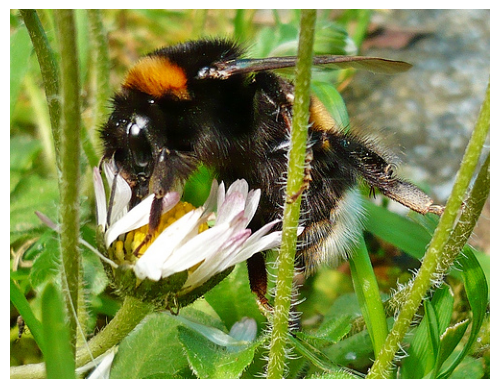

Original size: (500, 385)
Resized size: (224, 224)
Image array shape: (224, 224, 3)
Image data type: uint8


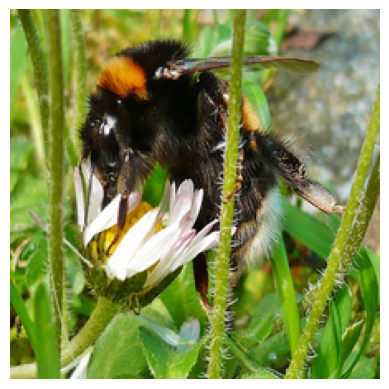

In [14]:

from PIL import Image
from tensorflow.keras.utils import image_dataset_from_directory
# Open the image file
image = Image.open('/home/acrfa/ml-class/mtre4820_project4/flowers-dataset/2481823240_eab0d86921.jpg')

# Convert the image to a NumPy array
image_array = np.asarray(image)

print(f"Image array shape: {image_array.shape}")
print(f"Image data type: {image_array.dtype}")

# Display the array as an image
plt.imshow(image_array)
plt.axis('off') # Optional: turns off axis numbers
plt.show()



# from PIL import Image

# # Open an image
# img = Image.open('original_image.jpg')
print(f"Original size: {image.size}")

# Define the new size as a tuple (width, height)
new_size = (224, 224) 

# Resize the image and assign the new image object to a variable
resized_img = image.resize(new_size, resample=Image.Resampling.LANCZOS) # Use a high-quality filter
print(f"Resized size: {resized_img.size}")

# Save the resized image
resized_img.save('resized_image.jpg')


# Convert the image to a NumPy array
image_array = np.asarray(resized_img)

print(f"Image array shape: {image_array.shape}")
print(f"Image data type: {image_array.dtype}")

# Display the array as an image
plt.imshow(image_array)
plt.axis('off') # Optional: turns off axis numbers
plt.show()



In [15]:
#create batches for the cnn

train_ds = image_dataset_from_directory(
    "/home/acrfa/ml-class/mtre4820_project4/flowers-dataset/flowers_split/train/",
    image_size=(224,224),
    batch_size=32
)

validation_ds = image_dataset_from_directory(
    "/home/acrfa/ml-class/mtre4820_project4/flowers-dataset/flowers_split/validation/",
    image_size=(224,224),
    batch_size=32
)

test_ds = image_dataset_from_directory(
    "/home/acrfa/ml-class/mtre4820_project4/flowers-dataset/flowers_split/test/",
    image_size=(224,224),
    batch_size=32
)




Found 2627 files belonging to 5 classes.
Found 1287 files belonging to 5 classes.
Found 1286 files belonging to 5 classes.


In [16]:
for i, (images, labels) in enumerate(train_ds):
    print(f"Batch {i+1}")
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Labels:", labels.numpy())

for i, (images, labels) in enumerate(validation_ds):
    print(f"Batch {i+1}")
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Labels:", labels.numpy())
for i, (images, labels) in enumerate(test_ds):
    print(f"Batch {i+1}")
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Labels:", labels.numpy())



Batch 1
Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Labels: [4 3 1 1 1 2 4 4 1 3 1 0 3 4 4 3 2 0 2 3 2 0 2 4 1 3 3 4 4 0 0 1]
Batch 2
Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Labels: [1 1 4 2 2 2 4 4 1 2 2 2 4 4 1 2 4 2 4 3 4 3 4 1 1 0 3 1 1 3 1 1]
Batch 3
Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Labels: [1 0 4 2 0 2 2 0 4 0 3 2 0 2 1 3 3 4 2 3 1 2 2 4 0 0 2 2 0 1 4 1]
Batch 4
Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Labels: [4 1 2 3 3 2 1 3 3 1 2 1 4 0 4 3 0 1 1 0 2 4 0 3 2 2 0 2 1 3 1 1]
Batch 5
Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Labels: [4 0 3 3 0 2 1 4 1 4 3 1 0 2 0 4 1 4 4 0 1 4 4 2 4 3 1 4 4 2 3 4]
Batch 6
Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Labels: [4 3 4 1 1 1 0 0 3 1 2 2 1 3 2 1 4 2 1 3 2 4 2 1 0 4 1 4 4 0 3 0]
Batch 7
Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Labels: [3 0 3 1 4 4 3 1 2 1 2 0 4 0 2 2 1 1 4 1 1 2 3 2 3 2 0 3 4 0 4 3]
Batch 8
Images shape: (32, 224, 224, 3)
Labels shape: (32,)
La

2026-03-27 14:34:30.663728: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Batch 13
Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Labels: [0 4 4 4 3 1 4 2 2 1 0 0 4 4 2 4 3 2 0 0 3 4 3 2 1 0 4 1 4 0 0 0]
Batch 14
Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Labels: [1 0 2 0 4 0 1 2 0 0 3 3 1 2 1 2 1 0 4 4 1 4 0 0 1 3 4 2 4 1 3 4]
Batch 15
Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Labels: [0 3 0 0 2 4 2 0 1 2 0 1 4 0 2 3 4 2 0 0 2 1 0 4 3 0 0 2 3 4 0 2]
Batch 16
Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Labels: [0 4 2 1 4 3 3 0 3 2 1 3 0 2 4 4 3 4 1 1 3 2 0 3 2 3 4 2 2 0 0 1]
Batch 17
Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Labels: [3 1 2 0 0 0 3 2 1 4 0 4 4 0 4 2 4 1 3 0 4 3 2 0 1 1 1 2 2 0 4 4]
Batch 18
Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Labels: [4 3 3 4 4 2 0 1 1 1 1 1 3 0 0 4 2 1 4 4 3 3 4 4 3 1 3 0 1 2 1 3]
Batch 19
Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Labels: [0 1 2 2 0 1 0 0 1 3 4 1 4 1 1 4 4 0 0 4 3 0 3 1 0 2 4 3 3 3 2 1]
Batch 20
Images shape: (32, 224, 224, 3)
Labels shape: 

Epoch 1/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 74s 855ms/step - accuracy: 0.3993 - loss: 1.4023 - val_accuracy: 0.4911 - val_loss: 1.1828
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 62s 742ms/step - accuracy: 0.5676 - loss: 1.0837 - val_accuracy: 0.6636 - val_loss: 0.8905
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 61s 734ms/step - accuracy: 0.6620 - loss: 0.8844 - val_accuracy: 0.7226 - val_loss: 0.7460
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 62s 743ms/step - accuracy: 0.7381 - loss: 0.7016 - val_accuracy: 0.7972 - val_loss: 0.5591
Epoch 5/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 62s 745ms/step - accuracy: 0.8333 - loss: 0.4651 - val_accuracy: 0.8570 - val_loss: 0.4290
Epoch 6/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 281s 3s/step - accuracy: 0.8835 - loss: 0.3352 - val_accuracy: 0.9207 - val_loss: 0.2576
Epoch 7/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 62s 744ms/step - accuracy: 0.9265 - loss: 0.1966 - val_accuracy: 0.9456 - val_loss: 0.2308
Epoch 8/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 61s 736ms/step - accuracy: 0.9391 - loss: 0.1715 - val_accura

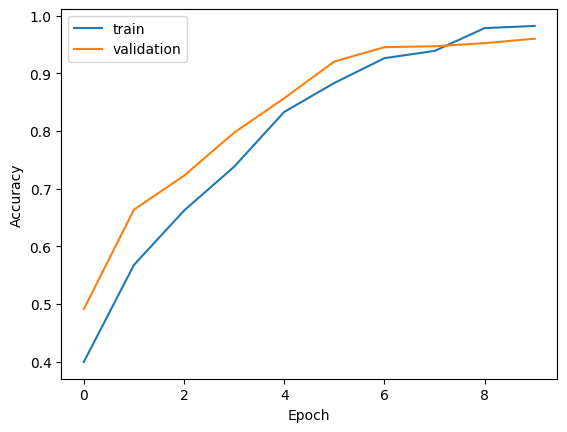

In [17]:
#CNN
#https://www.geeksforgeeks.org/deep-learning/convolutional-neural-network-cnn-in-tensorflow/
import tensorflow as tf
import matplotlib.pyplot as plt
 
#Need to normalize the images?
 
#CNN definition
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255,   input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # because labels are integers
    metrics=['accuracy']
)

 # Assuming you already have train_ds, validation_ds, test_ds
history = model.fit(
    train_ds,                  # contains both images and labels
    validation_data=validation_ds,
    epochs=10
)

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_ds)
print("Test accuracy:", test_accuracy)

# Optional: Plot training/validation accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [18]:
test_loss, test_accuracy = model.evaluate(test_ds)
print("Test accuracy:", test_accuracy)


41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 209ms/step - accuracy: 0.9588 - loss: 0.2376
Test accuracy: 0.9587869644165039
